In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
#Lab 10 - Task 1
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

df = pd.read_csv("/content/drive/MyDrive/housing.csv")

df = df[['GrLivArea', 'BedroomAbvGr', 'FullBath', 'SalePrice']]

df = df.dropna()

x = df[['GrLivArea', 'BedroomAbvGr', 'FullBath']]
y = df['SalePrice']


x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

LR = LinearRegression()
ModelLR = LR.fit(x_train, y_train)

PredictionLR = ModelLR.predict(x_test)


print("Predictions:", PredictionLR[:5])

mse = mean_squared_error(y_test, PredictionLR)
print("Mean Squared Error:", mse)

Predictions: [113410.67255298 305081.87775899 135904.78562983 205424.67564124
 227502.68349004]
Mean Squared Error: 2806426667.247853


In [8]:
#Lab 10 - Task 2
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.feature_extraction.text import CountVectorizer

df = pd.read_csv("/content/drive/MyDrive/emails.csv")


df = df[['text', 'spam']]

vectorizer = CountVectorizer()
x = vectorizer.fit_transform(df['text'])

y = df['spam']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# Train model
DT = DecisionTreeClassifier()
ModelDT = DT.fit(x_train, y_train)

PredictionDT = DT.predict(x_test)
print("Predictions:", PredictionDT[:10])

print('DT Training Accuracy')
TrainingAccDT = DT.score(x_train, y_train) * 100
print(f"Training Accuracy: {TrainingAccDT:.2f}%")

print('DT Testing Accuracy')
testingAccDT = accuracy_score(y_test, PredictionDT) * 100
print(f"Testing Accuracy: {testingAccDT:.2f}%")

Predictions: [0 0 0 0 0 1 0 0 0 1]
DT Training Accuracy
Training Accuracy: 100.00%
DT Testing Accuracy
Testing Accuracy: 95.64%


In [7]:
#Lab 10 - Task 3
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

df = pd.read_csv("/content/drive/MyDrive/Mall_Customers.csv")

df['HighValue'] = df['Spending Score (1-100)'].apply(lambda x: 1 if x > 50 else 0)

x = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]
y = df['HighValue']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

DT = DecisionTreeClassifier()
ModelDT = DT.fit(x_train, y_train)

PredictionDT = DT.predict(x_test)
print("Predictions:", PredictionDT[:10])

print('DT Training Accuracy')
TrainingAccDT = DT.score(x_train, y_train) * 100
print(f"Training Accuracy: {TrainingAccDT:.2f}%")

print('DT Testing Accuracy')
testingAccDT = accuracy_score(y_test, PredictionDT) * 100
print(f"Testing Accuracy: {testingAccDT:.2f}%")

Predictions: [1 1 0 0 0 0 0 0 0 1]
DT Training Accuracy
Training Accuracy: 100.00%
DT Testing Accuracy
Testing Accuracy: 100.00%


In [12]:
#Lab 11 - Task 1
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler


df = pd.read_csv("/content/drive/MyDrive/Mall_Customers.csv")

df['Genre'] = df['Genre'].map({'Male': 0, 'Female': 1})

x = df[['Genre', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']]

kmeans1 = KMeans(n_clusters=3, random_state=42)
df['Cluster_NoScaling'] = kmeans1.fit_predict(x)

print("Without Scaling:")
print(df['Cluster_NoScaling'].value_counts())

scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

kmeans2 = KMeans(n_clusters=3, random_state=42)
df['Cluster_WithScaling'] = kmeans2.fit_predict(x_scaled)

print("\nWith Scaling:")
print(df['Cluster_WithScaling'].value_counts())

Index(['CustomerID', 'Genre', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')
Without Scaling:
Cluster_NoScaling
0    124
1     41
2     35
Name: count, dtype: int64

With Scaling:
Cluster_WithScaling
2    94
0    71
1    35
Name: count, dtype: int64


In [13]:
#Lab 11 - Task 2
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Data
data = {
'vehicle_serial_no': [5,3,8,2,4,7,6,10,1,9],
'mileage': [150000,120000,250000,80000,100000,220000,180000,300000,75000,280000],
'fuel_efficiency': [15,18,10,22,20,12,16,8,24,9],
'maintenance_cost': [5000,4000,7000,2000,3000,6500,5500,8000,1500,7500],
'vehicle_type': ['SUV','Sedan','Truck','Hatchback','Sedan','Truck','SUV','Truck','Hatchback','SUV']
}

df = pd.DataFrame(data)

df['vehicle_type'] = df['vehicle_type'].astype('category').cat.codes

x = df.drop(columns=['vehicle_serial_no'])

kmeans1 = KMeans(n_clusters=3, random_state=42)
df['Cluster_NoScaling'] = kmeans1.fit_predict(x)

scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

kmeans2 = KMeans(n_clusters=3, random_state=42)
df['Cluster_WithScaling'] = kmeans2.fit_predict(x_scaled)

print(df)

   vehicle_serial_no  mileage  fuel_efficiency  maintenance_cost  \
0                  5   150000               15              5000   
1                  3   120000               18              4000   
2                  8   250000               10              7000   
3                  2    80000               22              2000   
4                  4   100000               20              3000   
5                  7   220000               12              6500   
6                  6   180000               16              5500   
7                 10   300000                8              8000   
8                  1    75000               24              1500   
9                  9   280000                9              7500   

   vehicle_type  Cluster_NoScaling  Cluster_WithScaling  
0             1                  2                    2  
1             2                  2                    2  
2             3                  1                    1  
3             0    

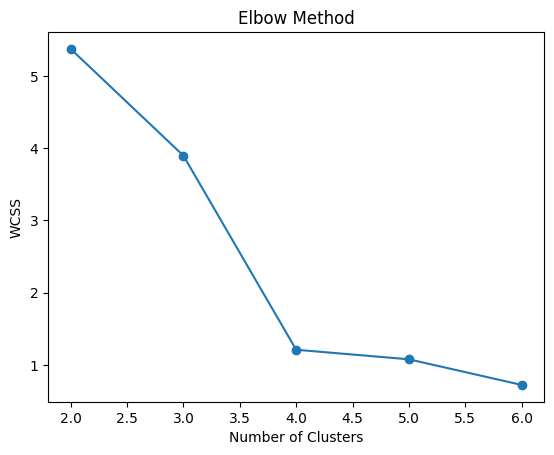

   student_id  Cluster
0           1        1
1           2        2
2           3        1
3           4        0
4           5        1
5           6        1
6           7        2
7           8        1
8           9        0
9          10        1


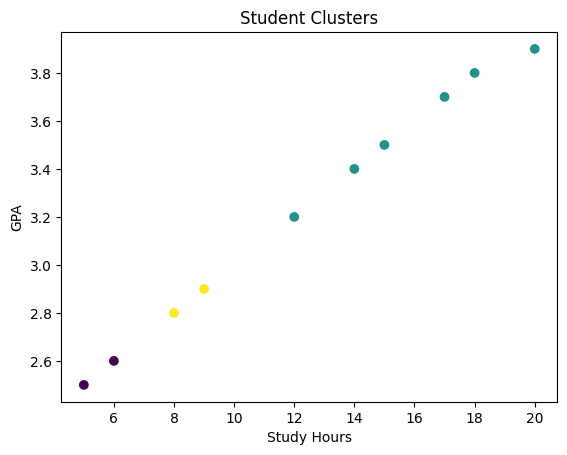

In [14]:
#Lab 11 - Task 3
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

data = {
'student_id': [1,2,3,4,5,6,7,8,9,10],
'GPA': [3.5,2.8,3.9,2.5,3.2,3.8,2.9,3.7,2.6,3.4],
'study_hours': [15,8,20,5,12,18,9,17,6,14],
'attendance_rate': [90,70,95,60,85,92,75,88,65,89]
}

df = pd.DataFrame(data)

x = df[['GPA', 'study_hours', 'attendance_rate']]

# Scaling
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

wcss = []

for i in range(2, 7):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(x_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(2,7), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(x_scaled)


print(df[['student_id', 'Cluster']])

plt.scatter(df['study_hours'], df['GPA'], c=df['Cluster'])
plt.xlabel("Study Hours")
plt.ylabel("GPA")
plt.title("Student Clusters")
plt.show()